# Analyze and compare clustering result (slide 11)

In [11]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys

import skimage
import skimage.io
import skimage.transform

import torch
import torch.hub
from MicNet_model import *

# 1) Read data

In [215]:
# Load previously generated gene statistics and files
gene_stat = pd.read_csv("./output/Dataset_MOB/spinal_gene_set_count_stats.csv", index_col=0)
cols = ["coords"]
cols.extend(gene_stat.columns.values)
image_dict = dict()
count_created = False
for image_id in [11]:
    _image_dict = torch.load("./output/Dataset_MOB/image_HE_Rep{}_MOB_dict.pt".format(image_id))
    _count = pd.read_csv("./output/Dataset_MOB/HE_Rep{}_MOB_count.csv".format(image_id), usecols=cols)
    
    # Update index
    _image_dict = dict(zip(["{}_{}".format(image_id, _) for _ in _image_dict.keys()], _image_dict.values()))
    image_dict.update(_image_dict)
    
    _count.loc[:, "coords"] = ["{}_{}".format(image_id, _) for _ in _count.loc[:, "coords"].values]
    _count = _count.set_index("coords")
    
    if count_created:
        count = pd.concat([count, _count])
    else:
        count = _count
        count_created = True

In [216]:
GT=pd.read_csv('./Sample_data/Dataset_MOB/GT_MOB.csv',index_col=0)
GT

,gt
10.802x9.131,2
10.861x10.031,2
10.877x11.024,2
10.882x16.005,0
10.889x20.06,1
...,...
9.919x21.027,4
9.922x20.102,3
9.927x19.137,3
9.938x16.03,1


In [217]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max value
tile_95 = np.log2(gene_stat.loc['max', :].values + 1)
tile_95[tile_95 < 1] = 1
count = count/tile_95

In [218]:
# Get indexes for each image/count point
indexes = list(set(image_dict.keys()) & set(count.index.values))
indexes.sort()
print("# of samples: {}".format(len(indexes)))

# Get indexes for testing set
indexes_test = [_ for _ in indexes if _.split("_")[0] not in ["1", "2", "3", "4"]]
print("# of testing samples: {}".format(len(indexes_test)))

# of samples: 262
# of testing samples: 262


In [219]:
# Sort count data
count = count.loc[indexes, :]

In [220]:
count.shape

(262, 19025)

# 2) Get image/gene features

In [221]:
# ----- Device -----
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

image_shape = image_dict[list(image_dict.keys())[0]].shape[0]
n_genes = gene_stat.shape[1]
n_data = len(indexes)
n_out_features = 100
imagenet = 'resnet101'
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, 
               imagenet=imagenet, genenet=[100, 100]).to(device)

Using device: cuda:0


In [222]:
model_dir = "./models/Dataset_MOB/"
checkpoint = torch.load(os.path.join(model_dir, "epoch_best.pt"), map_location=device)
model.load_state_dict(checkpoint['model'])

<All keys matched successfully>

In [223]:
model.eval()

from utils_data import Dataset
test_set = Dataset(indexes, image_dict, count, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=False, num_workers=1)

feat_images = []
feat_genes = []

with torch.no_grad():
    for idx, (data, index) in enumerate(test_loader):
        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        feat_images.append(feat_image.cpu().squeeze())
        feat_genes.append(feat_gene.cpu().squeeze())
        
# Normalize
feat_images = [_/sum(_**2)**0.5 for _ in feat_images]
feat_genes = [_/sum(_**2)**0.5 for _ in feat_genes]

torch.save((feat_images, feat_genes), "./output/Dataset_MOB/features_slide_11.pt")

In [224]:
# Combine to a big numpy matrix
image_feature = np.array([_.numpy() for _ in feat_images])
gene_feature = np.array([_.numpy() for _ in feat_genes])

# Normalize
image_feature = image_feature/(np.sum(image_feature**2, axis=1, keepdims=True)**0.5)
gene_feature = gene_feature/(np.sum(gene_feature**2, axis=1, keepdims=True)**0.5)

In [225]:
feat_images = image_feature
feat_genes = gene_feature
indexes_all = indexes
testing_indexes = indexes_test

# 3) Clustering

/project/DPDS/Xiao_lab/shared/qin_zhou/environments/envs/MicNet/lib/python3.6/site-packages/PIL/Image.py:2921: DecompressionBombWarning: Image size (91933800 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  DecompressionBombWarning,


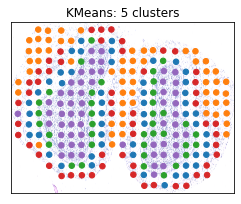

In [226]:
import matplotlib
from sklearn.cluster import KMeans, MiniBatchKMeans, SpectralClustering, DBSCAN


for seed in range(1):
    for image_id in [11]:
        image = skimage.io.imread("./Sample_data/Dataset_MOB//images/HE_Rep{}_MOB.jpg".format(image_id))
        _indexes_w_id = [_ for _ in indexes if int(_.split("_")[0]) == image_id]
        _indexes = [_.split("_")[1] for _ in _indexes_w_id]
        coords_x = np.array([float(_.split("x")[0]) for _ in _indexes])
        coords_y = np.array([float(_.split("x")[1]) for _ in _indexes])
        transformation = pd.read_table("./Sample_data/Dataset_MOB/transformation/Rep{}_MOB_transformation.txt".\
                                   format(image_id), sep=" ").columns.values.astype(float).reshape(3, 3).T
        transformation[2, 0] = 0
        transformation[2, 1] = 0
        tform = skimage.transform.AffineTransform(transformation)
        pixels_x = []
        pixels_y = []
        for i in range(len(coords_x)):
            [[x, y]] = tform([coords_x[i], coords_y[i]])
            pixels_x.append(x)
            pixels_y.append(y)
        coords_x = pixels_x
        coords_y = pixels_y
        xmin = np.min(pixels_x) - 200
        xmax = np.max(pixels_x) + 200
        ymin = np.min(pixels_y) - 200
        ymax = np.max(pixels_y) + 200

        cluster_df = pd.DataFrame(index=_indexes_w_id)
        # for n_clusters in range(2, 21):
        for n_clusters in [5]:
            _selected = [_ for _, _index in enumerate(indexes_all) if _index in _indexes_w_id]

            # Combined feature
            X = np.concatenate((image_feature, gene_feature), axis=1)
            X = X[_selected, ]
            X_filter = X[np.logical_not(np.any(np.isnan(X), 1)), :]

            method = KMeans(n_clusters=n_clusters, random_state=seed)  #0 for KMeans, 8 for MiniBatchKMeans
            name = "KMeans"
            model = method.fit(X_filter)
            Y = np.zeros([X.shape[0]])
            Y[:] = np.nan
            Y[np.logical_not(np.any(np.isnan(X), 1))] = model.labels_
            Y_image = Y.copy()

            # Match cluster from Y to Y_image
            Y_gene = Y.copy()
            Y = np.zeros_like(Y)
            Y[:] = np.nan
            matched_clusters = set()
            # Sort clusters from matched ratio high to low
            to_matched_clusters = np.argsort([np.max([np.sum(Y_image[Y_gene == to_matched_cluster] == _)/\
                                                      np.sum(Y_gene == to_matched_cluster)
                                                      for _ in range(n_clusters)])
                                              for to_matched_cluster in range(n_clusters)])[::-1]  
            # to_matched_clusters = np.argsort(np.bincount(Y_gene.astype(int)))[::-1]  # Sort clusters from big to small
            for to_matched_cluster in to_matched_clusters:
                corresponding_image_clusters = np.argsort([np.sum(Y_image[Y_gene == to_matched_cluster] == _) for _ in range(n_clusters)])[::-1]
                for corresponding_image_cluster in corresponding_image_clusters:
                    if corresponding_image_cluster not in matched_clusters:
                        # print(to_matched_cluster, corresponding_image_cluster)
                        Y[Y_gene == to_matched_cluster] = corresponding_image_cluster
                        matched_clusters = matched_clusters | set([corresponding_image_cluster])
                        break

            # Set color
            if n_clusters <= 10:
                cmap = plt.get_cmap("tab10")
            else:
                cmap = plt.get_cmap("tab20")
            _mycolor = [cmap(int(_)) for _ in Y]

            plt.figure(figsize=(4, 4))
            # plt.subplot(122)
            plt.imshow(np.clip(np.array(image + 100.), 0, 255).astype(np.uint8))
            fig = plt.scatter(coords_x, coords_y, c=_mycolor, s=30)
            plt.title('{}: {} clusters'.format(name, n_clusters))
            # plt.axis('off')
            fig.axes.get_xaxis().set_visible(False)
            fig.axes.get_yaxis().set_visible(False)
            plt.xlim(xmin, xmax)
            plt.ylim(ymax, ymin)
            plt.show()

            cluster_res_5_clusters.loc[:, "combinedfeature_{}_clusters".format(n_clusters)] = [int(_) for _ in Y]

ARI: 0.6765155041001342


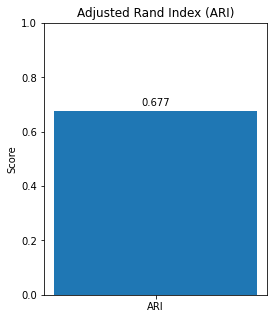

In [233]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
ari = adjusted_rand_score(GT['gt'], cluster_res_5_clusters['combinedfeature_5_clusters'])
print("ARI:", ari)

# ---- Plot ----
plt.figure(figsize=(4, 5))
plt.bar(['ARI'], [ari])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Adjusted Rand Index (ARI)")
for i, v in enumerate([ari]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.show()